# Objective :

"Predict behavior to retain customers. You can analyze all relevant customer data and develop focused customer retention programs."

# Step 1 :  Import Library and Dataset

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
employee = pd.read_csv(r"C:\Users\chaud\Downloads\carInsurance_data.csv")

employee.head(5)

,Id,Age,Job,Marital,Education,Default,Balance,HHInsurance,CarLoan,Communication,LastContactDay,LastContactMonth,NoOfContacts,DaysPassed,PrevAttempts,Outcome,CallStart,CallEnd,CarInsurance
0,1,32,management,single,tertiary,0,1218,1,0,telephone,28,jan,2,-1,0,NaN,13:45:20,13:46:30,0
1,2,32,blue-collar,married,primary,0,1156,1,0,NaN,26,may,5,-1,0,NaN,14:49:03,14:52:08,0
2,3,29,management,single,tertiary,0,637,1,0,cellular,3,jun,1,119,1,failure,16:30:24,16:36:04,1
3,4,25,student,single,primary,0,373,1,0,cellular,11,may,2,-1,0,NaN,12:06:43,12:20:22,1
4,5,30,management,married,tertiary,0,2694,0,0,cellular,3,jun,1,-1,0,NaN,14:35:44,14:38:56,0


# Step 2 : Data Pre-Processing

### Removing Irrelavent Variable

In [4]:
employee = employee.drop(['Id'],axis=1)
employee.columns

Index(['Age', 'Job', 'Marital', 'Education', 'Default', 'Balance',
       'HHInsurance', 'CarLoan', 'Communication', 'LastContactDay',
       'LastContactMonth', 'NoOfContacts', 'DaysPassed', 'PrevAttempts',
       'Outcome', 'CallStart', 'CallEnd', 'CarInsurance'],
      dtype='object')

### Univariate Analysis

In [5]:
employee.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               4000 non-null   int64 
 1   Job               3981 non-null   object
 2   Marital           4000 non-null   object
 3   Education         3831 non-null   object
 4   Default           4000 non-null   int64 
 5   Balance           4000 non-null   int64 
 6   HHInsurance       4000 non-null   int64 
 7   CarLoan           4000 non-null   int64 
 8   Communication     3098 non-null   object
 9   LastContactDay    4000 non-null   int64 
 10  LastContactMonth  4000 non-null   object
 11  NoOfContacts      4000 non-null   int64 
 12  DaysPassed        4000 non-null   int64 
 13  PrevAttempts      4000 non-null   int64 
 14  Outcome           958 non-null    object
 15  CallStart         4000 non-null   object
 16  CallEnd           4000 non-null   object
 17  CarInsurance  

In [20]:
employee.isna().sum()  

Age                    0
Job                    0
Marital                0
Education              0
Default                0
Balance                0
HHInsurance            0
CarLoan                0
Communication          0
LastContactDay         0
LastContactMonth       0
NoOfContacts           0
DaysPassed             0
PrevAttempts           0
Outcome             3042
CallStart              0
CallEnd                0
CarInsurance           0
dtype: int64

In [22]:
employee = employee.drop(columns=['Outcome'])


In [23]:
employee.isna().sum()  

Age                 0
Job                 0
Marital             0
Education           0
Default             0
Balance             0
HHInsurance         0
CarLoan             0
Communication       0
LastContactDay      0
LastContactMonth    0
NoOfContacts        0
DaysPassed          0
PrevAttempts        0
CallStart           0
CallEnd             0
CarInsurance        0
dtype: int64

In [12]:
employee.Job.fillna(employee.Job.mode()[0],inplace = True)

In [13]:
employee.Education.fillna(employee.Education.mode()[0],inplace = True)

In [14]:
employee.Communication.fillna(employee.Communication.mode()[0],inplace = True)

In [24]:
employee.isna().sum()  

Age                 0
Job                 0
Marital             0
Education           0
Default             0
Balance             0
HHInsurance         0
CarLoan             0
Communication       0
LastContactDay      0
LastContactMonth    0
NoOfContacts        0
DaysPassed          0
PrevAttempts        0
CallStart           0
CallEnd             0
CarInsurance        0
dtype: int64

In [25]:
employee.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               4000 non-null   int64 
 1   Job               4000 non-null   object
 2   Marital           4000 non-null   object
 3   Education         4000 non-null   object
 4   Default           4000 non-null   int64 
 5   Balance           4000 non-null   int64 
 6   HHInsurance       4000 non-null   int64 
 7   CarLoan           4000 non-null   int64 
 8   Communication     4000 non-null   object
 9   LastContactDay    4000 non-null   int64 
 10  LastContactMonth  4000 non-null   object
 11  NoOfContacts      4000 non-null   int64 
 12  DaysPassed        4000 non-null   int64 
 13  PrevAttempts      4000 non-null   int64 
 14  CallStart         4000 non-null   object
 15  CallEnd           4000 non-null   object
 16  CarInsurance      4000 non-null   int64 
dtypes: int64(10), 

### Outlier

<Axes: >

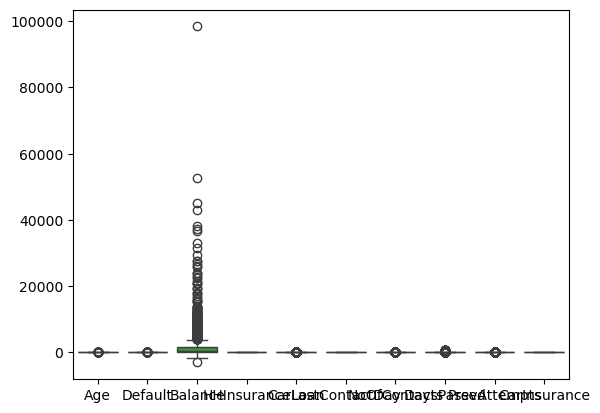

In [28]:
import seaborn as sns
sns.boxplot(data=employee)

Age outliers:	 0
Default outliers:	 0
Balance outliers:	 0
HHInsurance outliers:	 0
CarLoan outliers:	 0
LastContactDay outliers:	 0
NoOfContacts outliers:	 0
DaysPassed outliers:	 0
PrevAttempts outliers:	 0
CarInsurance outliers:	 0


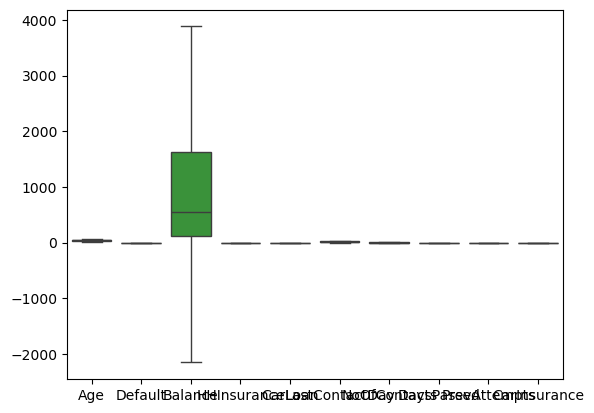

In [30]:
def outlier(employee):
    sns.boxplot(data=employee)
for i in employee:
    if employee[i].dtypes in ("float64","int64"):
        q1 = employee[i].quantile(0.25)
        q3 = employee[i].quantile(0.75)
        iqr = q3-q1
        ul = q3 + 1.5*iqr
        ll = q1 - 1.5*iqr
        employee[i].clip(upper=ul,lower=ll,inplace=True)
        
        outliers = employee[(employee[i] < ll) | (employee[i] > ul)]
        print(f"{i} outliers:\t", outliers.shape[0])

outlier(employee)

### Checking Missing Value

In [31]:
employee.isna().sum()  ## is = check & as = convert

Age                 0
Job                 0
Marital             0
Education           0
Default             0
Balance             0
HHInsurance         0
CarLoan             0
Communication       0
LastContactDay      0
LastContactMonth    0
NoOfContacts        0
DaysPassed          0
PrevAttempts        0
CallStart           0
CallEnd             0
CarInsurance        0
dtype: int64

In [32]:
employee.head()

,Age,Job,Marital,Education,Default,Balance,HHInsurance,CarLoan,Communication,LastContactDay,LastContactMonth,NoOfContacts,DaysPassed,PrevAttempts,CallStart,CallEnd,CarInsurance
0,32.0,management,single,tertiary,0,1218,1,0,telephone,28,jan,2,-1,0,13:45:20,13:46:30,0
1,32.0,blue-collar,married,primary,0,1156,1,0,cellular,26,may,5,-1,0,14:49:03,14:52:08,0
2,29.0,management,single,tertiary,0,637,1,0,cellular,3,jun,1,-1,0,16:30:24,16:36:04,1
3,25.0,student,single,primary,0,373,1,0,cellular,11,may,2,-1,0,12:06:43,12:20:22,1
4,30.0,management,married,tertiary,0,2694,0,0,cellular,3,jun,1,-1,0,14:35:44,14:38:56,0


# Churn Rate Analysis

In [33]:
employee.CarInsurance.value_counts(normalize=True)

CarInsurance
0    0.599
1    0.401
Name: proportion, dtype: float64

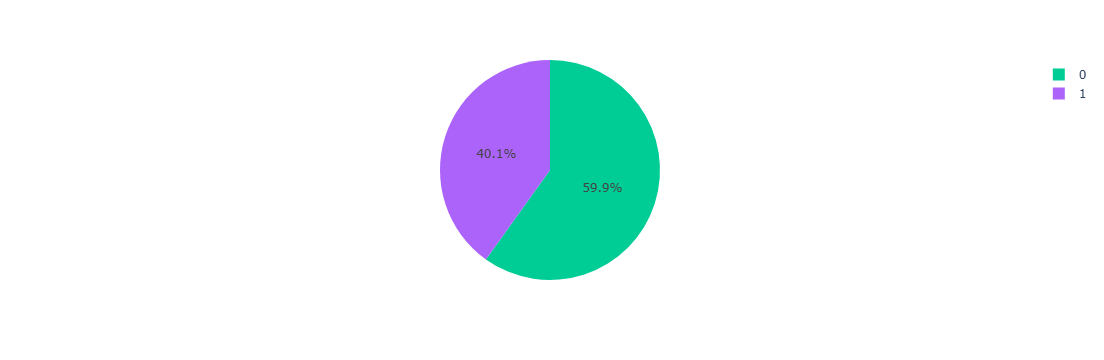

In [117]:
import plotly.express as px

fig = px.pie(employee,names='CarInsurance',color='CarInsurance',
             color_discrete_map={'Yes':'red',
                                 'No':'green'})
fig.show()

# Trend Analysis

In [35]:
employee.CarInsurance.value_counts()

CarInsurance
0    2396
1    1604
Name: count, dtype: int64

In [37]:
CarInsurance_Customer = employee.loc[employee["CarInsurance"] == "Yes",:]
CarInsurance_Customer.shape

(0, 17)

In [24]:
fig = px.sunburst(CarInsurance_Customer, path=["SeniorCitizen",'InternetService',
                                        "Contract", "PaymentMethod"])
fig.show()

#### Conclusion :- Customer Trend Analysis 

* Customer who leave the service are 
* Citizen = Youth , Internet =  Fiber Optic & Month-to-Month &  Payment = Electronic Check 

### Taking subset data of Number 

In [38]:
employee_num = employee.select_dtypes(include=[np.number])
employee_num.head(3)

,Age,Default,Balance,HHInsurance,CarLoan,LastContactDay,NoOfContacts,DaysPassed,PrevAttempts,CarInsurance
0,32.0,0,1218,1,0,28,2,-1,0,0
1,32.0,0,1156,1,0,26,5,-1,0,0
2,29.0,0,637,1,0,3,1,-1,0,1


### Taking subset data of Category 

In [40]:
employee = employee.drop(columns=['LastContactMonth',"CallStart","CallEnd"])


In [41]:
employee_dummies = employee.select_dtypes(include=['object'])
employee_dummies.head(3)

,Job,Marital,Education,Communication
0,management,single,tertiary,telephone
1,blue-collar,married,primary,cellular
2,management,single,tertiary,cellular


### Converting Quality Variable to Number

In [42]:
from sklearn.preprocessing import LabelEncoder

employee_dummies = employee_dummies.apply(LabelEncoder().fit_transform)
employee_dummies.head(3)

,Job,Marital,Education,Communication
0,4,2,2,1
1,1,1,0,0
2,4,2,2,0


### Combine to Dataset

In [43]:
employee_combined = pd.concat([employee_num, employee_dummies],axis=1)
employee_combined.head()

,Age,Default,Balance,HHInsurance,CarLoan,LastContactDay,NoOfContacts,DaysPassed,PrevAttempts,CarInsurance,Job,Marital,Education,Communication
0,32.0,0,1218,1,0,28,2,-1,0,0,4,2,2,1
1,32.0,0,1156,1,0,26,5,-1,0,0,1,1,0,0
2,29.0,0,637,1,0,3,1,-1,0,1,4,2,2,0
3,25.0,0,373,1,0,11,2,-1,0,1,8,2,0,0
4,30.0,0,2694,0,0,3,1,-1,0,0,4,1,2,0


#### EDA Completed

# Step 3: Data Partition

In [45]:
from sklearn.model_selection import train_test_split

x = employee_combined.drop(['CarInsurance'],axis=1)
y = employee_combined[['CarInsurance']]

X_train, X_test, y_train, y_test = train_test_split(x,y,test_size = 0.3,random_state=231)

# Step 4: Model Building

In [46]:
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor

dt = DecisionTreeClassifier(criterion='gini')  # by default it use Gini index for split
dt.fit(X_train,y_train)  # Model = dt

DecisionTreeClassifier()

# Step 5: Plotting the Tree 

In [47]:
train = pd.concat([y_train,X_train],axis=1)
train.head(2)

,CarInsurance,Age,Default,Balance,HHInsurance,CarLoan,LastContactDay,NoOfContacts,DaysPassed,PrevAttempts,Job,Marital,Education,Communication
3993,0,42.0,0,417,0,0,21,1,-1,0,9,2,1,0
2996,1,37.0,0,189,0,0,16,2,-1,0,9,1,1,0


In [48]:
independent_variable = list(train.columns[1:])
independent_variable

['Age',
 'Default',
 'Balance',
 'HHInsurance',
 'CarLoan',
 'LastContactDay',
 'NoOfContacts',
 'DaysPassed',
 'PrevAttempts',
 'Job',
 'Marital',
 'Education',
 'Communication']

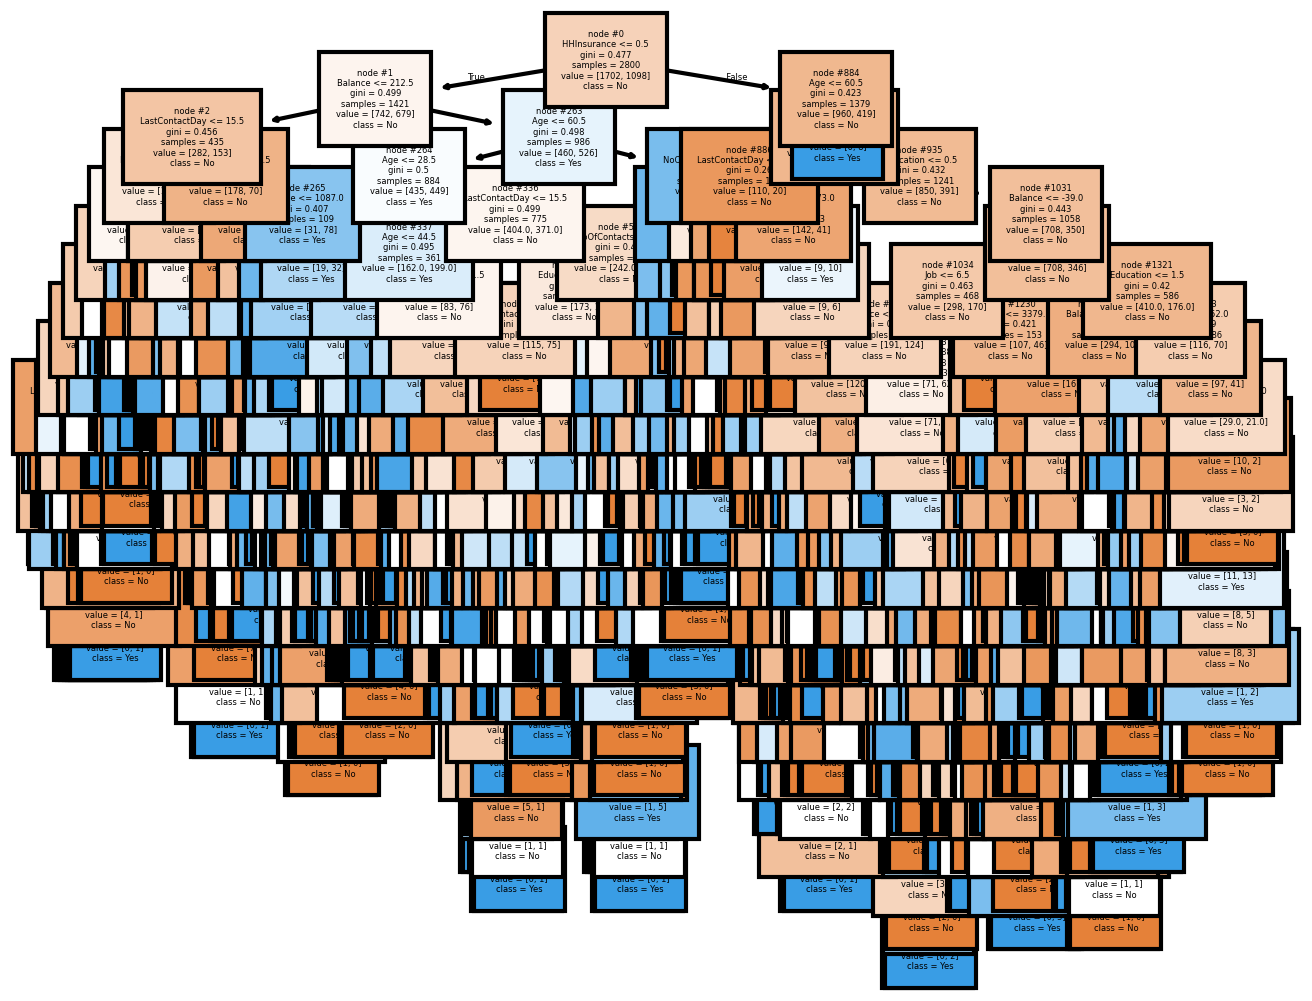

In [49]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (5,4), dpi=300)
plot_tree(dt,  # Model 
               feature_names = independent_variable,  # column name
               class_names = ['No', 'Yes'],  # array, #  No,Yes
               filled = True, # colour
              node_ids=True, # node number
              fontsize=2); # 
#fig.savefig('imagename.png')

# Step 6 : Predictions on Train Dataset

In [50]:
train.head()

,CarInsurance,Age,Default,Balance,HHInsurance,CarLoan,LastContactDay,NoOfContacts,DaysPassed,PrevAttempts,Job,Marital,Education,Communication
3993,0,42.0,0,417,0,0,21,1,-1,0,9,2,1,0
2996,1,37.0,0,189,0,0,16,2,-1,0,9,1,1,0
1436,1,54.0,0,0,0,0,13,1,-1,0,5,0,2,0
1017,0,31.0,0,1197,1,0,24,3,-1,0,9,1,2,0
351,0,39.0,0,241,1,0,18,2,-1,0,1,0,1,0


In [53]:
train['Predicted'] = dt.predict(X_train)  # MODEL = dt
train.head()

,CarInsurance,Age,Default,Balance,HHInsurance,CarLoan,LastContactDay,NoOfContacts,DaysPassed,PrevAttempts,Job,Marital,Education,Communication,Predicted
3993,0,42.0,0,417,0,0,21,1,-1,0,9,2,1,0,0
2996,1,37.0,0,189,0,0,16,2,-1,0,9,1,1,0,1
1436,1,54.0,0,0,0,0,13,1,-1,0,5,0,2,0,1
1017,0,31.0,0,1197,1,0,24,3,-1,0,9,1,2,0,0
351,0,39.0,0,241,1,0,18,2,-1,0,1,0,1,0,0


# Step 7 : Model Performance Metrics

In [118]:
from sklearn.metrics import confusion_matrix  
matrix = confusion_matrix(train['Predicted'],train['CarInsurance'])
print(matrix)

[[1367  554]
 [ 335  544]]


#### Final accuracy of Model Before Pruning 

In [120]:
Accuracy_Train=((1367+544)/(2800)*100)
print(Accuracy_Train)   # overfit or High accuracy

68.25


In [121]:
from sklearn.metrics import classification_report
print(classification_report(train['CarInsurance'], train['Predicted']))

              precision    recall  f1-score   support

           0       0.71      0.80      0.75      1702
           1       0.62      0.50      0.55      1098

    accuracy                           0.68      2800
   macro avg       0.67      0.65      0.65      2800
weighted avg       0.68      0.68      0.67      2800



* Model is overfitting , So we need control overfitting by doing pruning  

### Model Improvement by Pruning Method [ Cut Tree]

In [124]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(criterion='gini',  #splitter
                                 min_samples_split=1000, #parent 
                                 min_samples_leaf=700, ## child
                                 max_depth=5)  #branches
#Train the model using the training sets
dt.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=700,
                       min_samples_split=1000)

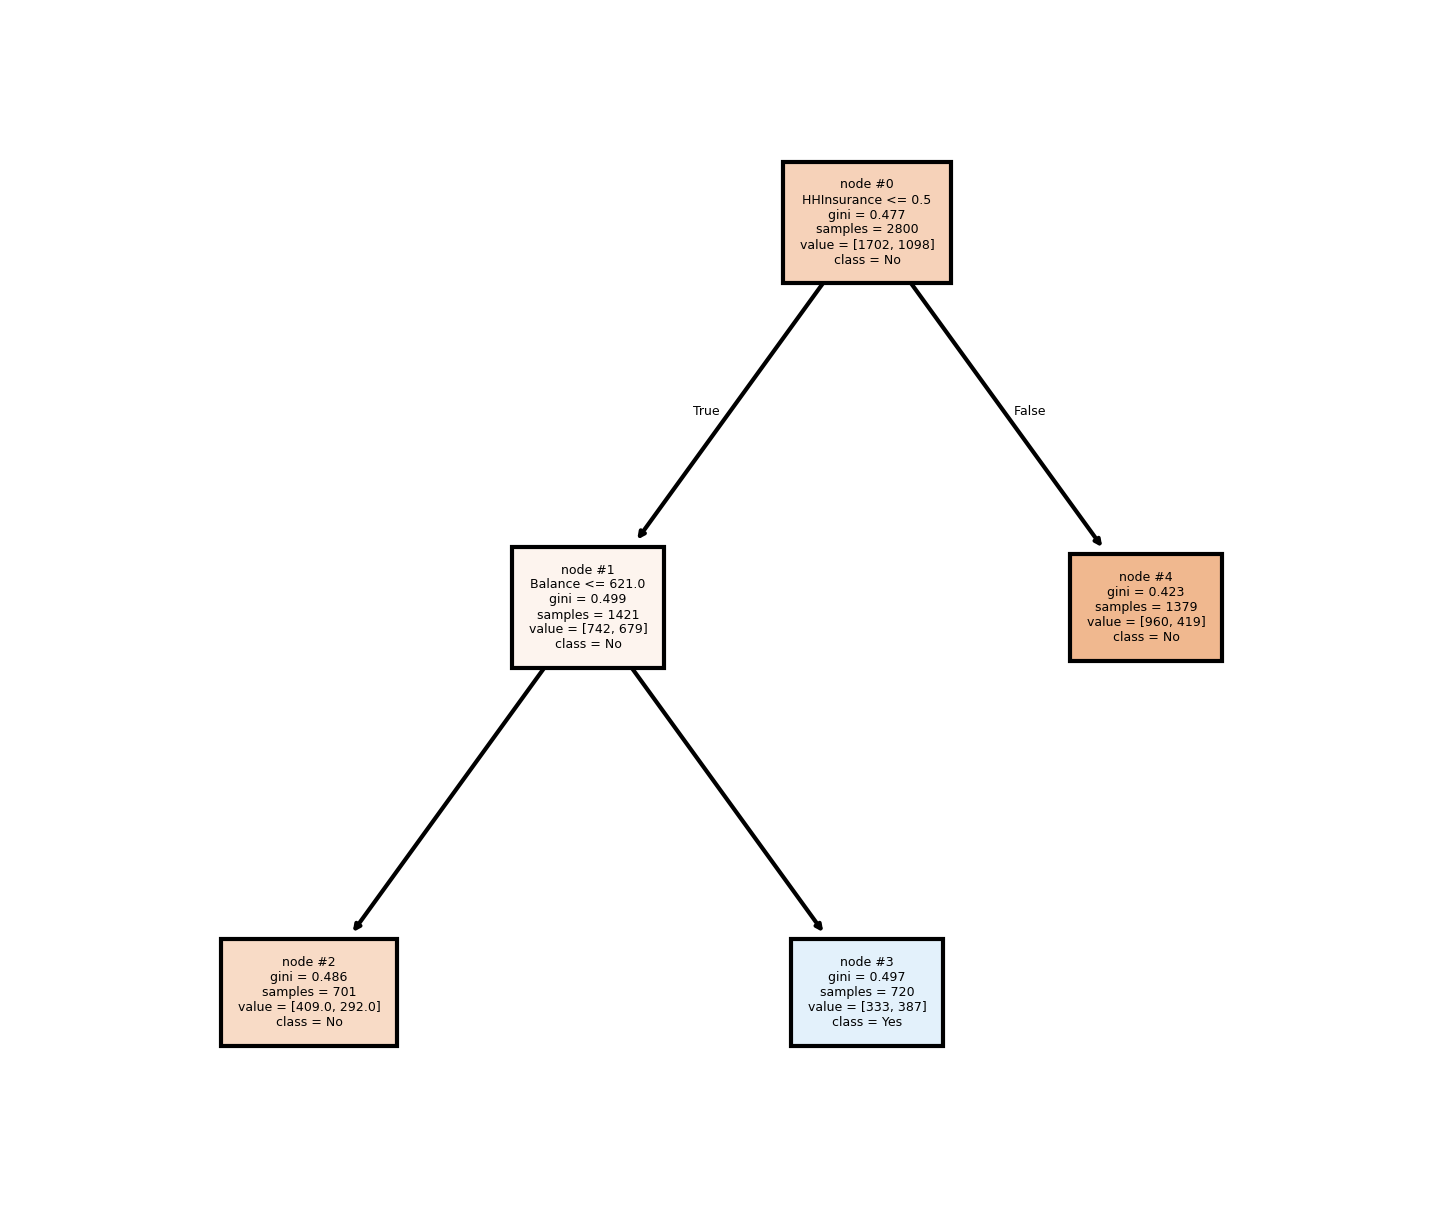

In [125]:
from sklearn import tree
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (6,5), dpi=300)
tree.plot_tree(dt,  # Model 
               feature_names = independent_variable,  # column name
               class_names = ['No', 'Yes'], # Yes , No
               filled = True, # colour
               node_ids = True, # node number
               fontsize=3); # 

# Importance Features

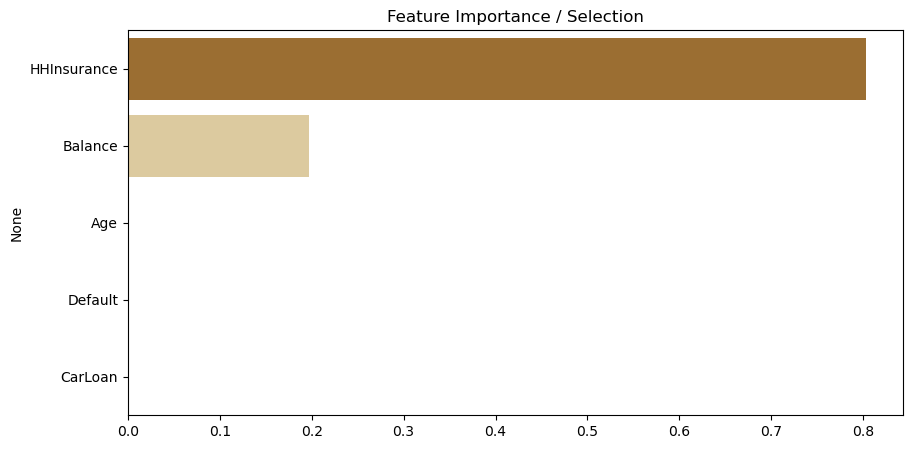

In [126]:
imp = pd.Series(data=dt.feature_importances_, index=dt.feature_names_in_).sort_values(ascending=False)
plt.figure(figsize=(10,5))
plt.title("Feature Importance / Selection")
ax = sns.barplot(y=imp.head().index, x=imp.head().values, palette="BrBG")

### Strategy & Prediction
* Contract = Month-to-Month & Monthly Charges > 68 & Tenure <= 15.5 

In [127]:
train['Predicted'] = dt.predict(X_train)  # MODEL = dt
train.head()

,CarInsurance,Age,Default,Balance,HHInsurance,CarLoan,LastContactDay,NoOfContacts,DaysPassed,PrevAttempts,Job,Marital,Education,Communication,Predicted
3993,0,42.0,0,417,0,0,21,1,-1,0,9,2,1,0,0
2996,1,37.0,0,189,0,0,16,2,-1,0,9,1,1,0,0
1436,1,54.0,0,0,0,0,13,1,-1,0,5,0,2,0,0
1017,0,31.0,0,1197,1,0,24,3,-1,0,9,1,2,0,0
351,0,39.0,0,241,1,0,18,2,-1,0,1,0,1,0,0


#### Final accuracy of Model after Pruning 

In [128]:
from sklearn.metrics import confusion_matrix  
matrix = confusion_matrix(train['Predicted'],train['CarInsurance'])
print(matrix)

[[1369  711]
 [ 333  387]]


In [108]:
sums=np.sum(1406+597+296+501)
sums

np.int64(2800)

In [129]:
Accuracy_Train=((1369 + 387)/(2800)*100)
print(Accuracy_Train)

62.71428571428571


In [82]:
from sklearn.metrics import classification_report
print(classification_report(train['CarInsurance'], train['Predicted']))

              precision    recall  f1-score   support

           0       0.67      0.87      0.76      1702
           1       0.62      0.32      0.42      1098

    accuracy                           0.66      2800
   macro avg       0.64      0.60      0.59      2800
weighted avg       0.65      0.66      0.63      2800



# Step 8 : Predictions on Test Dataset

In [65]:
test = pd.concat([X_test,y_test],axis=1)
test.head()

,Age,Default,Balance,HHInsurance,CarLoan,LastContactDay,NoOfContacts,DaysPassed,PrevAttempts,Job,Marital,Education,Communication,CarInsurance
2403,40.0,0,1,1,0,8,1,-1,0,1,2,1,0,0
3897,36.0,0,1207,1,0,19,2,-1,0,0,1,1,0,1
2052,43.0,0,3881,0,0,19,1,-1,0,4,1,2,0,0
3619,46.0,0,2196,0,0,28,5,-1,0,0,0,1,0,1
996,52.0,0,994,0,0,22,2,-1,0,1,1,0,0,0


In [66]:
test['Predicted'] = dt.predict(X_test)
test.head()

,Age,Default,Balance,HHInsurance,CarLoan,LastContactDay,NoOfContacts,DaysPassed,PrevAttempts,Job,Marital,Education,Communication,CarInsurance,Predicted
2403,40.0,0,1,1,0,8,1,-1,0,1,2,1,0,0,0
3897,36.0,0,1207,1,0,19,2,-1,0,0,1,1,0,1,0
2052,43.0,0,3881,0,0,19,1,-1,0,4,1,2,0,0,0
3619,46.0,0,2196,0,0,28,5,-1,0,0,0,1,0,1,0
996,52.0,0,994,0,0,22,2,-1,0,1,1,0,0,0,0


# Step 9 : Model Performance Metrics on Test data 

In [67]:
from sklearn.metrics import confusion_matrix
confusion_matrix = confusion_matrix(test['Predicted'],test['CarInsurance'])
print(confusion_matrix)

[[608 305]
 [ 86 201]]


In [68]:
sums=np.sum(608+305+86+201)
sums

np.int64(1200)

In [69]:
Accuracy_test=((608+201)/(1200)*100)
Accuracy_test

67.41666666666667

# Sensitivity & Specificity

#### Train

In [70]:
from sklearn.metrics import classification_report
print(classification_report(train['CarInsurance'], train['Predicted']))

              precision    recall  f1-score   support

           0       0.67      0.87      0.76      1702
           1       0.62      0.32      0.42      1098

    accuracy                           0.66      2800
   macro avg       0.64      0.60      0.59      2800
weighted avg       0.65      0.66      0.63      2800



#### Test

In [71]:
from sklearn.metrics import classification_report
print(classification_report(test['CarInsurance'], test['Predicted']))

              precision    recall  f1-score   support

           0       0.67      0.88      0.76       694
           1       0.70      0.40      0.51       506

    accuracy                           0.67      1200
   macro avg       0.68      0.64      0.63      1200
weighted avg       0.68      0.67      0.65      1200



* 49% is accuracy of bad customer capture by model 
* 89% is accuracy of Good customer capture by model 

# Grid Search Method 

In [86]:
params = { 'min_samples_split': [500,600], ## Parent 
           'min_samples_leaf': [100,250], ## Child or Leave 
           'max_depth':[4,5,6]}  # Branches

In [87]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

grid_search_cv = GridSearchCV(DecisionTreeClassifier(random_state=42),
                              params, 
                              verbose=1, 
                              cv=10)
grid_search_cv.fit(X_train, y_train)

Fitting 10 folds for each of 12 candidates, totalling 120 fits


GridSearchCV(cv=10, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'max_depth': [4, 5, 6], 'min_samples_leaf': [100, 250],
                         'min_samples_split': [500, 600]},
             verbose=1)

In [88]:
grid_search_cv.best_estimator_

DecisionTreeClassifier(max_depth=6, min_samples_leaf=100, min_samples_split=500,
                       random_state=42)

# Finished

# Live Data

In [55]:
Live_data_dec = X_test.iloc[0:5,:]
Live_data_dec

,tenure,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
1358,10,70.15,735.50,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,3
5471,29,74.20,1993.25,0,0,0,0,1,1,1,0,0,0,0,0,0,0,1,2
2693,72,19.30,1414.80,1,0,0,0,1,0,2,0,0,0,0,0,0,2,0,0
1077,41,114.50,4527.45,0,0,0,0,1,1,1,1,1,1,1,1,1,0,1,0
6663,1,54.65,54.65,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,2


In [56]:
Live_data_dec['Predicted'] = dt.predict(Live_data_dec)
Live_data_dec

,tenure,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Predicted
1358,10,70.15,735.50,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,3,1
5471,29,74.20,1993.25,0,0,0,0,1,1,1,0,0,0,0,0,0,0,1,2,0
2693,72,19.30,1414.80,1,0,0,0,1,0,2,0,0,0,0,0,0,2,0,0,0
1077,41,114.50,4527.45,0,0,0,0,1,1,1,1,1,1,1,1,1,0,1,0,0
6663,1,54.65,54.65,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,2,1


# Business Submission

In [57]:
print(classification_report(train['Churn'], train['Predicted']))

              precision    recall  f1-score   support

           0       0.84      0.89      0.87      3617
           1       0.65      0.55      0.59      1313

    accuracy                           0.80      4930
   macro avg       0.75      0.72      0.73      4930
weighted avg       0.79      0.80      0.79      4930



# Model Export

In [59]:
import pickle

pickle.dump(dt, open(r"C:\Users\chaud\OneDrive.pkl",'wb'))  #model = dt # Exporting model from python to laptop

In [60]:
X_train.head()

,tenure,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
1583,6,48.95,273.25,0,0,1,1,1,1,0,0,0,0,0,0,0,0,1,1
6791,19,39.65,733.35,1,0,0,0,0,0,0,0,0,1,0,1,0,0,1,2
4812,9,66.25,620.55,0,0,0,0,1,0,0,0,1,0,1,1,0,0,0,3
6282,4,19.55,68.80,1,0,1,1,1,0,2,0,0,0,0,0,0,2,0,1
2479,56,75.85,4261.20,1,0,1,1,1,1,0,1,1,0,1,0,1,2,1,1


In [61]:
employee.Partner.value_counts()

Partner
No     3641
Yes    3402
Name: count, dtype: int64